# Pandas Basics

### Use of AI: can be used, but must be reported.
### AI shall not be used to complete the whole assignment.

## Execute every code cell and also take a look at the code and try to understand what is happening.

* Always wait until the cell is run. If you get errors, fix them before going any further.
* Example codes will help you in doing the tasks, understand the examples before going further.
* Do not alter the ready made code.

Topics:
- Recap Pandas basic operations
- Usage of loc and iloc
- Removal of columns and rows
- Filling missing data


In [103]:
# Take libraries in use
import pandas as pd
import numpy as np
import matplotlib as mp
import matplotlib.pyplot as plt
import seaborn as sns

## Let's use the Titanic dataset today.

## Task 1
* Familiarize yourself with the Titanic dataset: https://github.com/mwaskom/seaborn-data/blob/master/titanic.csv

Then answer these questions (briefly):


1. How many columns there are in the Titanic dataset?
2. Are there missing values?
3. What are the three ports (towns) of emabarkation?



In [104]:
# Load the Titanic data
df = sns.load_dataset('titanic')

'''
1. Number of columns (features) of the dataset is 15
2. Missing value columns
    survived       False
    pclass         False
    sex            False
    age             True
    sibsp          False
    parch          False
    fare           False
    embarked        True
    class          False
    who            False
    adult_male     False
    deck            True
    embark_town     True
    alive          False
    alone          False
3. All ports of the dataset: ['Southampton' 'Cherbourg' 'Queenstown']
'''


"\n1. Number of columns (features) of the dataset is 15\n2. Missing value columns\n    survived       False\n    pclass         False\n    sex            False\n    age             True\n    sibsp          False\n    parch          False\n    fare           False\n    embarked        True\n    class          False\n    who            False\n    adult_male     False\n    deck            True\n    embark_town     True\n    alive          False\n    alone          False\n3. All ports of the dataset: ['Southampton' 'Cherbourg' 'Queenstown']\n"

Let's find out the usual things from the dataset that are always good the check.

In [105]:
# Checking that the data is read correctly
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [106]:
# Checking general info form the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


## Task 2
Which columns contain missing values?

Write your answer here:

In [107]:
# More information (somewhat overlapping with info())
df.shape

# the columns that have missing data (NaN)
print("- Number of columns (features) of the dataset is", len(df.columns))
print("- Missing value columns")
print(df.isna().any())

- Number of columns (features) of the dataset is 15
- Missing value columns
survived       False
pclass         False
sex            False
age             True
sibsp          False
parch          False
fare           False
embarked        True
class          False
who            False
adult_male     False
deck            True
embark_town     True
alive          False
alone          False
dtype: bool


In [108]:
# And descriptive statistics
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## How to select certain rows and cells in DataFrame

Sometimes there is a need to refer to data based on its location or variable name (and/or basic indexing with [] is not enough).
Pandas has following methods to use:
- iloc
- loc

### iloc - Selecting data based on its index

Rows are given numerical values <start>:<end>
- The rows from index <start> to <end> -1 are selected
- For example, 5:7, the values of the 5th and **6th** rows are selected
- If you don't give the start AND end values of the rows, but only : , then all rows
- -1 means the last row

Columns respectively
- For example 2:5, when the columns from **2 to 4** are selected
- If you don't give the start AND end numbers of the columns, but only : , then all columns
- -1 means the last column


##### Examples with rows and columns
- iloc[5:7, 2:5] selects data from rows 5 and 6 and columns 2, 3 and 4
- iloc[ : , 0:1 ] selects data from all rows and the first column
- iloc[ : , -1] selects data from all rows and the the last column


In [109]:
df.head(10)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
5,0,3,male,NaN,0,0,8.4583,Q,Third,man,True,NaN,Queenstown,no,True
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
7,0,3,male,2.0,3,1,21.0750,S,Third,child,False,NaN,Southampton,no,False
8,1,3,female,27.0,0,2,11.1333,S,Third,woman,False,NaN,Southampton,yes,False
9,1,2,female,14.0,1,0,30.0708,C,Second,child,False,NaN,Cherbourg,yes,False


In [110]:
df.iloc[0:3,0:8]  # rows in indexes 0-2 and columns in index 0-7

,survived,pclass,sex,age,sibsp,parch,fare,embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S


## Task 3

In [111]:
# Show all rows for columns 2 - 9 using iloc
# Write your code here
df1 = df.iloc[:, 2:10]
df1.head()

,sex,age,sibsp,parch,fare,embarked,class,who
0,male,22.0,1,0,7.2500,S,Third,man
1,female,38.0,1,0,71.2833,C,First,woman
2,female,26.0,0,0,7.9250,S,Third,woman
3,female,35.0,1,0,53.1000,S,First,woman
4,male,35.0,0,0,8.0500,S,Third,man


In [112]:
# Show rows 10 - 15 for columns "survived" and "pclass" using iloc
# Write your code here

survivedIndex = df.columns.get_loc("survived")
pclassIndex = df.columns.get_loc("pclass")

df2 = df.iloc[10:16, survivedIndex:pclassIndex + 1]

df2.head(10)


# What if the survived and pclass are not next to each other in the dataframe...? What would you do?

# My NOTES: If the survived and the pclass are not next to each other, the code above will select all columns from survivedIndex to pclassIndex
# In this case, we can use the code bellow

df2 = df.iloc[10:16, [survivedIndex, pclassIndex]]

df2.head(10)

,survived,pclass
10,1,3
11,1,1
12,0,3
13,0,3
14,0,3
15,1,2


### loc - Selecting data based on the name of the variable in column (in first row)

loc selects the values of columns by specifying the column names for specified rows

- Rows are given numerical values (if them are not renamed to have names)
- Variable names are given as columns.
- Note: if you like select several variables you specify the the first and last

##### Example:

- loc [:, 'fare' ] selects the values of the variable 'fare' from all rows
- loc [0:5, 'class':'deck'] selects the values of the variables from 'class' to 'deck' from rows 0-4

In [113]:
df.head(20)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
5,0,3,male,NaN,0,0,8.4583,Q,Third,man,True,NaN,Queenstown,no,True
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
7,0,3,male,2.0,3,1,21.0750,S,Third,child,False,NaN,Southampton,no,False
8,1,3,female,27.0,0,2,11.1333,S,Third,woman,False,NaN,Southampton,yes,False
9,1,2,female,14.0,1,0,30.0708,C,Second,child,False,NaN,Cherbourg,yes,False


In [114]:
df.loc[:15, 'survived':'embark_town']  # first rows 0 - 15 and columns from 'survived' to 'embark_town'

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton
5,0,3,male,NaN,0,0,8.4583,Q,Third,man,True,NaN,Queenstown
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton
7,0,3,male,2.0,3,1,21.0750,S,Third,child,False,NaN,Southampton
8,1,3,female,27.0,0,2,11.1333,S,Third,woman,False,NaN,Southampton
9,1,2,female,14.0,1,0,30.0708,C,Second,child,False,NaN,Cherbourg


In [115]:
# Names of all columns
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')

## Task 4

In [116]:
# Show first 10 rows for last 3 variables in the dataframe using loc
# Write your code here

df3 = df.loc[:10, 'embark_town':'alone']
df3.head(10)

,embark_town,alive,alone
0,Southampton,no,False
1,Cherbourg,yes,False
2,Southampton,yes,True
3,Southampton,yes,False
4,Southampton,no,True
5,Queenstown,no,True
6,Southampton,no,True
7,Southampton,no,False
8,Southampton,yes,False
9,Cherbourg,yes,False


## How to select certain columns or rows from data - summary
1. Pandas basic indexing (works, but has some limitations):

    df_new = df[['Column1', 'Column2', 'Column3', 'Column4','Column5']]

2. Use **'loc'** - method: 

    df_new = df.loc [:, ['Column1', 'Column2', 'Column3', 'Column4','Column5']]

3. Use **'iloc'** - method:

    df_new = df.iloc [:, n:m] # to select columns from index n to m-1


Columns:

    2 : n -> All positions from index 2 up to index n-1
    -1 -> Last position
    -3 : -1 -> Three last positions

Rows:

    2 : n -> All row positions from index 2 up to index n
    -1 -> Last position
    -3 : -1 -> Three last positions


### Removing data

#### Remove columns with 'drop'

In [117]:
# Let's check the column names again
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')

In [118]:
# Remove certain columns
df.drop(columns = 'alive')

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,True


In [119]:
df.drop(columns = ['parch', 'embarked', 'who','alive'])

,survived,pclass,sex,age,sibsp,fare,class,adult_male,deck,embark_town,alone
0,0,3,male,22.0,1,7.2500,Third,True,NaN,Southampton,False
1,1,1,female,38.0,1,71.2833,First,False,C,Cherbourg,False
2,1,3,female,26.0,0,7.9250,Third,False,NaN,Southampton,True
3,1,1,female,35.0,1,53.1000,First,False,C,Southampton,False
4,0,3,male,35.0,0,8.0500,Third,True,NaN,Southampton,True
...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,13.0000,Second,True,NaN,Southampton,True
887,1,1,female,19.0,0,30.0000,First,False,B,Southampton,True
888,0,3,female,NaN,1,23.4500,Third,False,NaN,Southampton,False
889,1,1,male,26.0,0,30.0000,First,True,C,Cherbourg,True


##### Note: the operation does NOT affect to orginal DataFrame
- DataFrame still contains the variables
- If you like to modify DataFrame, you need to store result in existing DataFrame
- Another option (better) is to store data in new DataFrame

In [120]:
# df still contain same data
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


##### To remove the columns one way is to store the result in other DataFrame


In [121]:
# Result in same DataFrame
df2 = df.drop(columns = ['parch', 'embarked', 'who','alive'])
df2.head()

,survived,pclass,sex,age,sibsp,fare,class,adult_male,deck,embark_town,alone
0,0,3,male,22.0,1,7.2500,Third,True,NaN,Southampton,False
1,1,1,female,38.0,1,71.2833,First,False,C,Cherbourg,False
2,1,3,female,26.0,0,7.9250,Third,False,NaN,Southampton,True
3,1,1,female,35.0,1,53.1000,First,False,C,Southampton,False
4,0,3,male,35.0,0,8.0500,Third,True,NaN,Southampton,True


## Task 5

In [122]:
# Remove columns 'adult_male' and 'sibsp', modify the df2 dataframe
# Write your code here
df2 = df2.drop(columns=['adult_male', 'sibsp'])

# Then check with df2.head() that you succeeded.
# Write your code here

df2.head()

,survived,pclass,sex,age,fare,class,deck,embark_town,alone
0,0,3,male,22.0,7.2500,Third,NaN,Southampton,False
1,1,1,female,38.0,71.2833,First,C,Cherbourg,False
2,1,3,female,26.0,7.9250,Third,NaN,Southampton,True
3,1,1,female,35.0,53.1000,First,C,Southampton,False
4,0,3,male,35.0,8.0500,Third,NaN,Southampton,True


##### Missing data can found e.g. using DataFrame methods 'isna' or 'isnull'

In [123]:
df.isna()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
887,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
888,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False
889,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [124]:
df.isnull()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
887,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
888,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False
889,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


### Removing rows with dropna()

- We can drop all rows with 'dropna'
- dropna remove rows with null values

In [125]:
# Result contain only rows where all variables have data
df2 = df.dropna()
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 182 entries, 1 to 889
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     182 non-null    int64   
 1   pclass       182 non-null    int64   
 2   sex          182 non-null    object  
 3   age          182 non-null    float64 
 4   sibsp        182 non-null    int64   
 5   parch        182 non-null    int64   
 6   fare         182 non-null    float64 
 7   embarked     182 non-null    object  
 8   class        182 non-null    category
 9   who          182 non-null    object  
 10  adult_male   182 non-null    bool    
 11  deck         182 non-null    category
 12  embark_town  182 non-null    object  
 13  alive        182 non-null    object  
 14  alone        182 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 18.2+ KB


Looks like we lost a lot of rows when dropping all that are missing information.
It is not always a good option to drop all rows with missing data.

### Store other value if missing data
- e.g. mean or median for quantitative data
- or mode for qualitative data
- or use specific value, e.g. 0

These can be done with DataFrame method 'fillna'

In [126]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


##### Example: Store mean value as the variable 'age' if value is missing

<Axes: xlabel='age', ylabel='Count'>

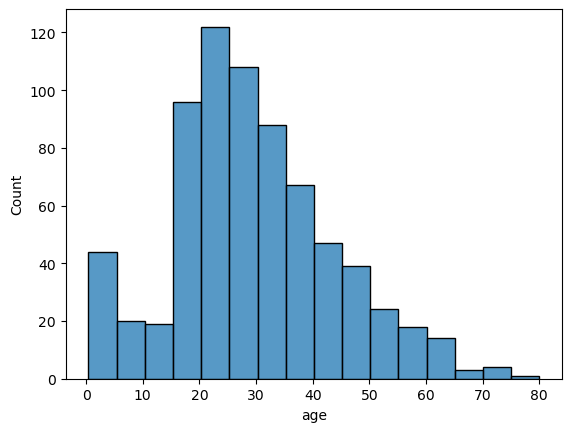

In [127]:
# Check data before the operation
sns.histplot(data = df, x = 'age', binwidth = 5)

In [128]:
agemean = df.age.mean()
agemean

np.float64(29.69911764705882)

In [129]:
# Let's first make a copy of the original dataset, name of the copy is df3
df3 = df

# Then fill the age with mean
df3['age'] = df['age'].fillna(agemean)
df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          891 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


<Axes: xlabel='age', ylabel='Count'>

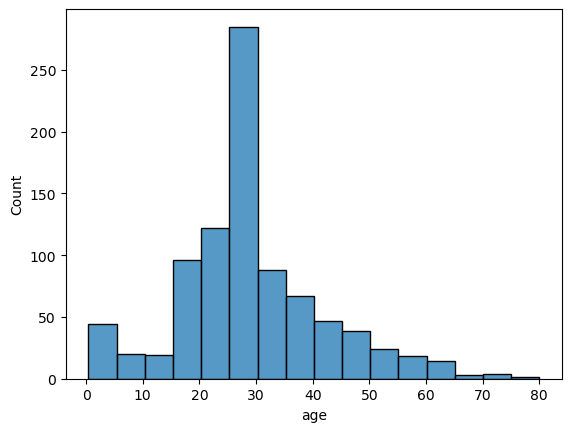

In [130]:
# Check data after the operation
sns.histplot(data = df3, x = 'age', binwidth = 5)

## Task 6: Find how to add mode value using Fillna(). Modify the df3 dataframe.
- First select one categorical variable that has missing values.
- Check how many different values the variable has (hint: unique()) and visualise this (hint: bar chart).
- Then find out the mode and use fillna.
- Check that the changes are made (visualise).

In [131]:
# Your code here.
# It is good the divide the code into multiple cells, so add code cells if necessary.

In [132]:
# Select one categorical variable that has missing values
print(df3.isna().any())

survived       False
pclass         False
sex            False
age            False
sibsp          False
parch          False
fare           False
embarked        True
class          False
who            False
adult_male     False
deck            True
embark_town     True
alive          False
alone          False
dtype: bool


Unique values from embarked category: ['S' 'C' 'Q' nan]


<Axes: xlabel='embarked', ylabel='Count'>

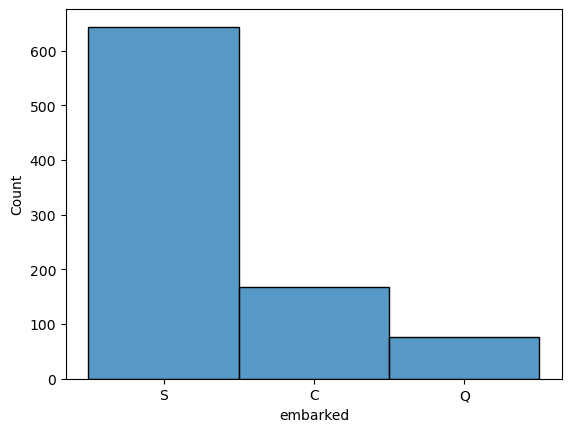

In [133]:
# I choose the embarked category, since it has the NaN value
print("Unique values from embarked category:", df3.loc[:, 'embarked'].unique())

# Visualizae with bar chart
sns.histplot(data=df3, x='embarked', bins=3) # 3 unique values

In [134]:
# Fill NaN values with other values
df3['embarked'] = df3['embarked'].fillna('X')

<Axes: xlabel='embarked', ylabel='Count'>

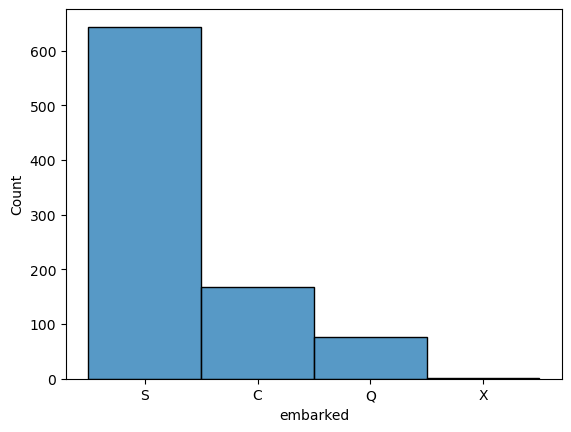

In [135]:
# Visualizae with bar chart
sns.histplot(data=df3, x='embarked', bins=4)

### Grouping data with 'groupby'

In [136]:
df.groupby('class').head(3)

/var/folders/jy/rp50v7rd5pjccn7vcb6nrlq80000gn/T/ipykernel_74992/3296768235.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('class').head(3)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.000000,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.000000,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.000000,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.000000,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.000000,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
6,0,1,male,54.000000,0,0,51.8625,S,First,man,True,E,Southampton,no,True
9,1,2,female,14.000000,1,0,30.0708,C,Second,child,False,NaN,Cherbourg,yes,False
15,1,2,female,55.000000,0,0,16.0000,S,Second,woman,False,NaN,Southampton,yes,True
17,1,2,male,29.699118,0,0,13.0000,S,Second,man,True,NaN,Southampton,yes,True


## Task 7
* Did the previous code give some future warning?
* If yes, about what? If not, then move to the question below.
* Which value of observed-parameter of the groupby()-funcion should you use, True or False?

In [137]:
# The previous code has warning: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. 
# Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

In [138]:
df3 = df.groupby('pclass').describe()
df3.head()

survived                                                 age  \
          count      mean       std  min  25%  50%  75%  max  count   
pclass                                                                
1         216.0  0.629630  0.484026  0.0  0.0  1.0  1.0  1.0  216.0   
2         184.0  0.472826  0.500623  0.0  0.0  0.0  1.0  1.0  184.0   
3         491.0  0.242363  0.428949  0.0  0.0  0.0  0.0  1.0  491.0   

                   ... parch        fare                                       \
             mean  ...   75%  max  count       mean        std  min       25%   
pclass             ...                                                          
1       37.048118  ...   0.0  4.0  216.0  84.154687  78.380373  0.0  30.92395   
2       29.866958  ...   1.0  3.0  184.0  20.662183  13.417399  0.0  13.00000   
3       26.403259  ...   0.0  6.0  491.0  13.675550  11.778142  0.0   7.75000   

                                 
            50%   75%       max  
pclass                           
1       60.2875  93.5  512.3292  
2       14.2500  26.0   73.5000  
3        8.0500  15.5   69.5500  

[3 rows x 40 columns]

In [139]:
df3.head().transpose()

pclass                   1           2           3
survived count  216.000000  184.000000  491.000000
         mean     0.629630    0.472826    0.242363
         std      0.484026    0.500623    0.428949
         min      0.000000    0.000000    0.000000
         25%      0.000000    0.000000    0.000000
         50%      1.000000    0.000000    0.000000
         75%      1.000000    1.000000    0.000000
         max      1.000000    1.000000    1.000000
age      count  216.000000  184.000000  491.000000
         mean    37.048118   29.866958   26.403259
         std     14.046369   13.573825   10.815245
         min      0.920000    0.670000    0.420000
         25%     29.000000   23.000000   20.250000
         50%     35.000000   29.699118   29.699118
         75%     47.250000   36.000000   29.699118
         max     80.000000   70.000000   74.000000
sibsp    count  216.000000  184.000000  491.000000
         mean     0.416667    0.402174    0.615071
         std      0.611898    0.601633    1.374883
         min      0.000000    0.000000    0.000000
         25%      0.000000    0.000000    0.000000
         50%      0.000000    0.000000    0.000000
         75%      1.000000    1.000000    1.000000
         max      3.000000    3.000000    8.000000
parch    count  216.000000  184.000000  491.000000
         mean     0.356481    0.380435    0.393075
         std      0.693997    0.690963    0.888861
         min      0.000000    0.000000    0.000000
         25%      0.000000    0.000000    0.000000
         50%      0.000000    0.000000    0.000000
         75%      0.000000    1.000000    0.000000
         max      4.000000    3.000000    6.000000
fare     count  216.000000  184.000000  491.000000
         mean    84.154687   20.662183   13.675550
         std     78.380373   13.417399   11.778142
         min      0.000000    0.000000    0.000000
         25%     30.923950   13.000000    7.750000
         50%     60.287500   14.250000    8.050000
         75%     93.500000   26.000000   15.500000
         max    512.329200   73.500000   69.550000

### Addition of new variable (column)

In [140]:
# Let's make another copy of the original dataframe
df4 = df
df4['fare_age'] = df['fare'] / df['age']
df4.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,fare_age
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False,0.329545
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,1.875876
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True,0.304808
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,1.517143
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True,0.230000


### Conditions

In [141]:
df5 = df.loc[(df['age'] > 25) & (df['class'] =='First')]
df5

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,fare_age
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,1.875876
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,1.517143
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True,0.960417
11,1,1,female,58.0,0,0,26.5500,S,First,woman,False,C,Southampton,yes,True,0.457759
23,1,1,male,28.0,0,0,35.5000,S,First,man,True,A,Southampton,yes,True,1.267857
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
867,0,1,male,31.0,0,0,50.4958,S,First,man,True,A,Southampton,no,True,1.628897
871,1,1,female,47.0,1,1,52.5542,S,First,woman,False,D,Southampton,yes,False,1.118174
872,0,1,male,33.0,0,0,5.0000,S,First,man,True,B,Southampton,no,True,0.151515
879,1,1,female,56.0,0,1,83.1583,C,First,woman,False,C,Cherbourg,yes,False,1.484970


## Task 8
Create a dataframe df6 that contains only survived female passangers who embarked in Cherbourg.

In [142]:
# Write your code here
df6 = df.loc[(df['alive'] == 'yes') & (df['embark_town'] == 'Cherbourg')]

# And check, what happened to df6
# Write your code here

df6.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,fare_age
1,1,1,female,38.000000,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,1.875876
9,1,2,female,14.000000,1,0,30.0708,C,Second,child,False,NaN,Cherbourg,yes,False,2.147914
19,1,3,female,29.699118,0,0,7.2250,C,Third,woman,False,NaN,Cherbourg,yes,True,0.243273
31,1,1,female,29.699118,1,0,146.5208,C,First,woman,False,B,Cherbourg,yes,False,4.933507
36,1,3,male,29.699118,0,0,7.2292,C,Third,man,True,NaN,Cherbourg,yes,True,0.243415


### Task 6, AI statement
- I used AI to support me correct python syntax errors.


### Task return
- File > Save and Export Notebook As > HTML
- Then take a look the produced HTML that it looks ok and readable
- Return to Itslearning, only the html document is returned, *not the .ipynb